In [1]:
import numpy as np
import matplotlib.pyplot as plt
from geometry_class import Geometry
from parametrizations_CrippaMoure_adapted import Parameter
from visualization_fct import get_grid, eval_fct_on_grid
from dolfinx.fem import functionspace, Function, Expression
import pickle
from basix.ufl import element
import ufl
from scipy.interpolate import griddata

In [2]:
layer_params = [{
    "top": {"d_i": 0.406e-3, "rho_s": 444,
        "locator": lambda x: x[1] >= 0.1},
    "bottom": {"d_i": 1.463e-3, "rho_s": 484,
        "locator": lambda x: x[1] < 0.1},
        },
        {
    "top": {"d_i": 0.406e-3, "rho_s": 442,
        "locator": lambda x: x[1] >= 0.08},
    "bottom": {"d_i": 1.463e-3, "rho_s": 487,
        "locator": lambda x: x[1] < 0.08},
        },
        {
    "top": {"d_i": 0.406e-3, "rho_s": 455,
        "locator": lambda x: x[1] >= 0.1},
    "bottom": {"d_i": 1.463e-3, "rho_s": 510,
        "locator": lambda x: x[1] < 0.1},
        }]
def Se(h_c, alpha, N):
    return (1 + (- alpha * h_c)**N)**((1 - N) / N)
LWCs = []
times = []
z_lines = []

for i in range(3):
    filename = "./solutions/Test_Avanzi_FM" + str(i+1) + ".pkl"
    with open(filename, "rb") as f:
        data_Annika = pickle.load(f)
    nx = data_Annika["geometry"]["nx"]
    nz = data_Annika["geometry"]["nz"]
    geom = Geometry()
    geom.make_from_dict(data_Annika["geometry"])
    domain = geom.make_domain(nx, nz)
    [P0, P1, P2, P3] = geom.corner_points
    V = functionspace(domain, ("CG", 1))
    Q = functionspace(domain, ("DG", 0))
    hw = Function(V)
    phi = Function(Q)
    p = Parameter(domain, layer_params[i])
    hw.x.array[:] = data_Annika["h_w"][-1]
    phi.x.array[:] = data_Annika["phi"]
    z_line = np.linspace(P0[1], P3[1], nz+1)
    x_data = P1[0]/2*np.ones_like(z_line)
    grid = np.column_stack((x_data, z_line))
    pressure_head = eval_fct_on_grid(grid, hw, domain)
    porosity = eval_fct_on_grid(grid, phi, domain)
    h_c = pressure_head * (pressure_head < 0)
    alpha_eval = eval_fct_on_grid(grid, p.alpha, domain)
    N_eval = eval_fct_on_grid(grid, p.N, domain)
    LWCs.append(p.theta_r.value + (0.9*porosity - p.theta_r.value)*Se(h_c, alpha_eval, N_eval))
    times.append(data_Annika["times"][-1])
    z_lines.append(z_line)



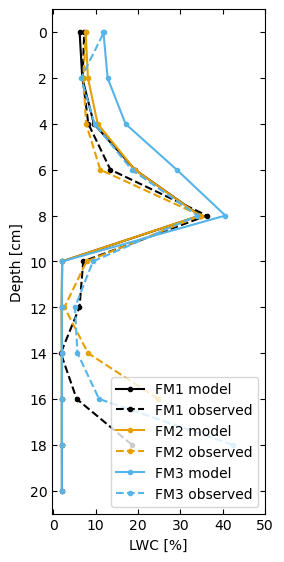

In [4]:
depths = [np.linspace(0, 18, 10), np.linspace(0, 16, 9), np.linspace(0, 18, 10)]
FM1 = np.array(
    [7.314, 6.916, 8.274, 13.488, 36.230, 7.069, 6.190, 1.774, 5.525, 18.572])
FM2 = np.array(
    [7.715, 7.096, 7.751, 11.090, 34.737, 7.850, 2.631, 8.198, 24.754])
FM3 = np.array(
    [11.965, 6.584, 9.743, 18.523, 33.998, 9.353, 5.124, 5.702, 10.815, 42.317])
Experiments = [FM1, FM2, FM3]

colors = ['#000000', '#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7'] # colour-blind friendly palette (Okabe-Ito)
fig, ax = plt.subplots(1,1, figsize=(2.75,6.55))
for i in range(3):
    color = colors[i % len(colors)]
    ax.plot(LWCs[i]*100, np.flip(z_lines[i])*100,
              ".-", label=f"FM{i+1} model", color=color)
    ax.plot(np.flip(Experiments[i]), np.flip(depths[i]),
             ".--", label=f"FM{i+1} observed", color=color)
ax.set_xlabel("LWC [%]")
ax.set_ylabel("Depth [cm]")
ax.invert_yaxis()
ax.set_yticks(np.linspace(0, 20, 11))
ax.set_xticks(np.linspace(0, 50, 6))
ax.tick_params(tick2On=True, direction="in")
ax.legend(loc="lower right")

In [24]:
# get average of 2cm slices
avg_LWC = []
for j in range(3):
    avg_LWC.append([100*np.mean(LWCs[j][i:i+4]) for i in range(1, len(LWCs[j]), 4)])